# 3. results and analysis of the trained model

**what this notebook shows:** accuracy at three levels, the confusion matrix, calibration, class imbalance and the classical machine learning baselines (pca, lda, svm, knn and others). the numbers are for the first model (`runs/stage1`) on its 4,232 test images. the saved model outputs are used, so this runs in seconds.

In [1]:
# find the project folder, so the notebook works from any place
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root / "src"))
print("project folder:", root)

project folder: C:\Users\91738\edge-waste


In [2]:
# load the saved outputs of the model on the validation and test images
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from edgewaste import taxonomy as tx
from edgewaste.analysis import calibration as cal

val = np.load("runs/analysis/convnext_vit/cache_val.npz", allow_pickle=True)
test = np.load("runs/analysis/convnext_vit/cache_test.npz", allow_pickle=True)
names = list(test["class_names"])
y_val, y_test = val["labels"].astype(int), test["labels"].astype(int)
fam_of = np.array([tx.FAMILY_TO_INDEX[tx.CLASS_TO_FAMILY[n]] for n in names])    # family number of each class
haz = tx.FAMILY_TO_INDEX["hazardous"]
print("test images:", len(y_test), "| validation images:", len(y_val))

test images: 4232 | validation images: 4232


## accuracy at three levels

- **item accuracy**: the exact class is right
- **family accuracy**: the bin is right (this is what sorting needs)
- **hazard recall**: of all dangerous items, how many were called dangerous

In [3]:
# the three headline numbers, computed by hand so the code is easy to read
from sklearn.metrics import f1_score, balanced_accuracy_score, top_k_accuracy_score
pred = test["logits"].argmax(1)
item_acc = (pred == y_test).mean()
family_acc = (fam_of[pred] == fam_of[y_test]).mean()
is_haz = fam_of[y_test] == haz
haz_recall = (fam_of[pred][is_haz] == haz).mean()
print(f"item accuracy    : {item_acc * 100:.2f}%")
print(f"family accuracy  : {family_acc * 100:.2f}%")
print(f"hazard recall    : {haz_recall * 100:.2f}%  ({int((fam_of[pred][is_haz] == haz).sum())} of {int(is_haz.sum())})")
print(f"macro f1         : {f1_score(y_test, pred, average='macro'):.3f}")
print(f"balanced accuracy: {balanced_accuracy_score(y_test, pred) * 100:.2f}%")
print(f"top-3 accuracy   : {top_k_accuracy_score(y_test, test['logits'], k=3, labels=range(33)) * 100:.2f}%")

item accuracy    : 89.30%
family accuracy  : 94.14%
hazard recall    : 93.50%  (690 of 738)
macro f1         : 0.863
balanced accuracy: 86.78%
top-3 accuracy   : 96.74%


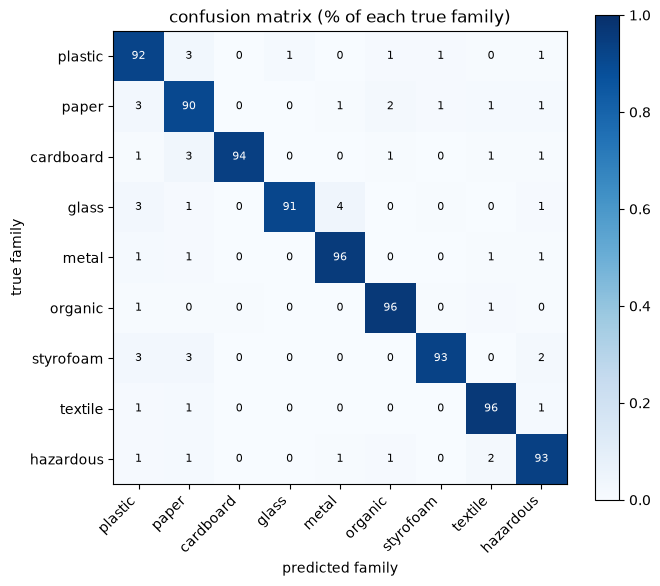

In [4]:
# confusion matrix at family level: rows are the true family, columns are the predicted family
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(fam_of[y_test], fam_of[pred], labels=range(len(tx.FAMILIES)), normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(9)); ax.set_xticklabels(tx.FAMILIES, rotation=45, ha="right")
ax.set_yticks(range(9)); ax.set_yticklabels(tx.FAMILIES)
for i in range(9):
    for j in range(9):
        ax.text(j, i, f"{cm[i, j] * 100:.0f}", ha="center", va="center", fontsize=8, color="white" if cm[i, j] > 0.5 else "black")
ax.set_xlabel("predicted family"); ax.set_ylabel("true family"); ax.set_title("confusion matrix (% of each true family)")
plt.colorbar(im); plt.tight_layout(); plt.show()

In [5]:
# which pairs of classes get mixed up most? (almost always inside one family)
cm_item = confusion_matrix(y_test, pred, labels=range(33))
np.fill_diagonal(cm_item, 0)
pairs = np.dstack(np.unravel_index(np.argsort(-cm_item.ravel())[:8], cm_item.shape))[0]
for t, p in pairs:
    same = "same family" if fam_of[t] == fam_of[p] else "DIFFERENT family"
    print(f"{names[t]:26s} -> {names[p]:26s} {cm_item[t, p]:3d} times   ({same})")

cardboard_packaging        -> cardboard_boxes             33 times   (same family)
steel_food_cans            -> aluminum_food_cans          29 times   (same family)
cardboard_boxes            -> cardboard_packaging         21 times   (same family)
aluminum_food_cans         -> steel_food_cans             18 times   (same family)
clothing                   -> shoes                       15 times   (same family)
e_waste                    -> medical                     12 times   (same family)
medical                    -> e_waste                     10 times   (same family)
clothing                   -> office_paper                 7 times   (DIFFERENT family)


## calibration: can we trust the confidence?

the model is *under-confident*: it is right more often than it says. one number T (temperature), fitted on the validation set, fixes this without changing any prediction.

In [6]:
# fit the temperature on validation data, then check on test data
T = cal.fit_temperature(val["logits"], y_val)
before = cal.calibration_stats(cal.softmax(test["logits"]), y_test)
after = cal.calibration_stats(cal.softmax(test["logits"], T), y_test)
print(f"temperature T = {T:.2f}")
print(f"{'':22s}{'before':>10s}{'after':>10s}")
for k in ("ece", "nll", "brier", "mean_confidence", "accuracy"):
    print(f"{k:22s}{before[k]:10.3f}{after[k]:10.3f}")
print("predictions unchanged:", bool((cal.softmax(test['logits'], T).argmax(1) == pred).all()))

temperature T = 0.71
                          before     after
ece                        0.166     0.073
nll                        0.651     0.534
brier                      0.232     0.183
mean_confidence            0.730     0.897
accuracy                   0.893     0.893
predictions unchanged: True


## class imbalance

some classes have many more images than others. the first model corrected this twice. here we shift the scores after training with `score + tau * log(class size)` and choose tau on the validation set only.

In [7]:
# post-training logit adjustment
train_df = pd.read_csv("data/splits_colab_reconstructed.csv")
train_df = train_df[train_df["split"] == "train"]
n_train = train_df["class_name"].value_counts().reindex(names).values.astype(float)
def acc_with(tau, logits, y):
    return ((logits + tau * np.log(n_train)).argmax(1) == y).mean()
taus = [0, 0.5, 1.0, 1.5, 1.75, 2.0, 2.5]
rows = [(t, acc_with(t, val["logits"], y_val) * 100) for t in taus]
best_tau = max(rows, key=lambda r: r[1])[0]
print("tau   validation accuracy")
for t, a in rows:
    print(f"{t:4.2f}  {a:6.2f}%" + ("   <- chosen on validation" if t == best_tau else ""))
print(f"\ntest accuracy: {acc_with(0, test['logits'], y_test) * 100:.2f}% before, {acc_with(best_tau, test['logits'], y_test) * 100:.2f}% after (tau = {best_tau})")

tau   validation accuracy
0.00   89.51%
0.50   89.58%
1.00   89.77%
1.50   90.03%
1.75   90.05%   <- chosen on validation
2.00   90.03%
2.50   89.20%

test accuracy: 89.30% before, 89.60% after (tau = 1.75)


## classical machine learning baselines (pca, lda, svm, knn, random forest ...)

the same test images were also classified with classical methods on three kinds of features. this answers: *why deep learning?* and *does the deep model beat simple methods?*

In [8]:
# results of the baselines (made by src/edgewaste/analysis/classical_baselines.py)
b = pd.read_csv("reports/ml_analysis/classical_baselines.csv")
tab = b.pivot(index="model", columns="feature_set", values="test_accuracy").mul(100).round(1)
tab = tab[["handcrafted", "imagenet_frozen", "finetuned_embedding"]]
print("test accuracy (%) of each classifier on each feature set:")
display(tab)
print("our fine-tuned hybrid with its own softmax head: 89.3%")

test accuracy (%) of each classifier on each feature set:


feature_set,handcrafted,imagenet_frozen,finetuned_embedding
model,,,
gaussian_naive_bayes,40.5,84.5,88.5
knn,61.4,91.6,89.7
lda,47.7,89.5,89.5
linear_svm,50.8,91.9,89.8
logistic_regression,52.6,92.5,89.2
random_forest,57.1,91.5,88.9
rbf_svm,71.1,93.3,89.2


our fine-tuned hybrid with its own softmax head: 89.3%


In [9]:
# how many pca components are needed to keep 95% of the information? (fewer = more compact features)
import json
pca = json.load(open("reports/ml_analysis/summary.json"))["classical_baselines"]["pca"]
print(f"{'feature set':22s}{'raw size':>10s}{'for 90%':>10s}{'for 95%':>10s}{'for 99%':>10s}")
for name, v in pca.items():
    print(f"{name:22s}{v['raw_dim']:10d}{v['n_components_90pct']:10d}{v['n_components_95pct']:10d}{v['n_components_99pct']:10d}")
print("the fine-tuned features are very compact: 29 numbers keep 95% of the information")

feature set             raw size   for 90%   for 95%   for 99%
handcrafted                 1860       439       715      1325
imagenet_frozen              768       382       513       690
finetuned_embedding         1024        23        29        45
the fine-tuned features are very compact: 29 numbers keep 95% of the information


### what the baselines tell us

1. hand-made features (colour + hog) with the best classical model reach only about **71%**. deep features reach **89-93%**. so deep learning is needed.
2. naive bayes and lda have the lowest train-test gap but low accuracy (high bias). random forest and knn fit the training set almost perfectly but lose accuracy on test (high variance).
3. an svm on **frozen** imagenet features (93.3%) was better than our first fine-tuned model (89.3%). this showed that fine-tuning had damaged the pretrained features, and led to the improved recipe (93.83% on colab).